In [3]:
import os
import re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DOCS_PATH = Path("../docs/raw/docs-apim/en/docs")
print(DOCS_PATH.resolve())
print("Docs path exists:", DOCS_PATH.exists())

HIGH_VALUE_FOLDERS = [
    "get-started",
    "api-design-manage", 
    "api-gateway",
    "api-security",
    "ai-gateway",
    "install-and-setup",
    "tutorials",
    "use-cases"
]

print("Docs path exists:", DOCS_PATH.exists())

/Users/heshangamage/ws02-devassist/docs/raw/docs-apim/en/docs
Docs path exists: True
Docs path exists: True


In [4]:
all_files = []

print("DOCS_PATH:", DOCS_PATH.resolve())
print("DOCS_PATH exists:", DOCS_PATH.exists())

for folder in HIGH_VALUE_FOLDERS:
    folder_path = DOCS_PATH / folder
    if folder_path.exists():
        files = list(folder_path.rglob("*.md"))
        for f in files:
            all_files.append({
                "folder": folder,
                "path": str(f),
                "filename": f.name,
                "size_lines": len(f.read_text(encoding="utf-8", errors="ignore").splitlines()),
            })

df = pd.DataFrame(all_files, columns=["folder", "path", "filename", "size_lines"])
print(f"Total files: {len(df)}")

if df.empty:
    print("No files found. Check DOCS_PATH and HIGH_VALUE_FOLDERS.")
else:
    print("\nFiles per folder:")
    print(df.groupby("folder")["filename"].count().sort_values(ascending=False))

DOCS_PATH: /Users/heshangamage/ws02-devassist/docs/raw/docs-apim/en/docs
DOCS_PATH exists: True
Total files: 350

Files per folder:
folder
install-and-setup    84
api-design-manage    79
api-security         53
ai-gateway           47
api-gateway          47
tutorials            31
get-started           8
use-cases             1
Name: filename, dtype: int64


count     350.000000
mean      157.854286
std       164.179558
min         9.000000
25%        62.000000
50%       102.000000
75%       187.000000
max      1018.000000
Name: size_lines, dtype: float64


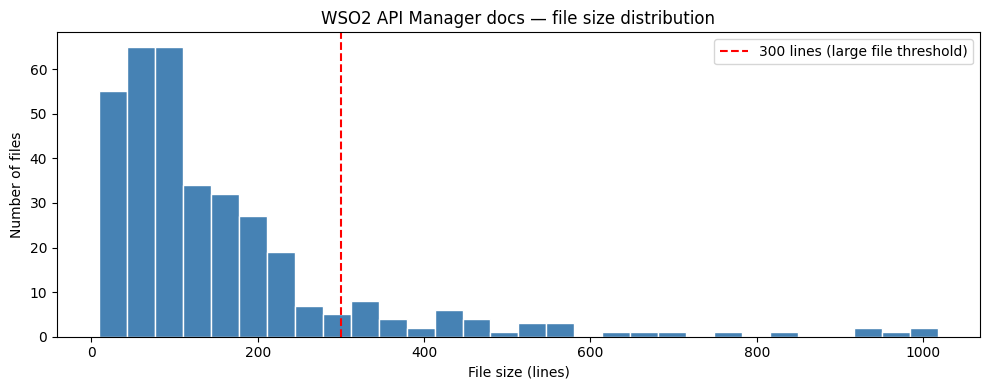


Files over 300 lines: 43
                folder                                           filename  \
293  install-and-setup                   am-pattern-5-all-in-one-gw-km.md   
286  install-and-setup                       am-pattern-4-acp-tm-gw-km.md   
291  install-and-setup                am-pattern-6-all-in-one-is-as-km.md   
288  install-and-setup                          am-pattern-3-acp-tm-gw.md   
292  install-and-setup                      am-pattern-2-all-in-one-gw.md   
290  install-and-setup                      am-pattern-1-all-in-one-ha.md   
258  install-and-setup  deploying-wso2-api-m-in-a-simple-scalable-setu...   
294  install-and-setup                         am-pattern-0-all-in-one.md   
246  install-and-setup   security-guidelines-for-production-deployment.md   
281  install-and-setup         configuring-a-read-only-ldap-user-store.md   

     size_lines  
293        1018  
286        1004  
291         952  
288         948  
292         932  
290         843  


In [5]:
print(df['size_lines'].describe())

plt.figure(figsize=(10, 4))
plt.hist(df['size_lines'], bins=30, color='steelblue', edgecolor='white')
plt.axvline(300, color='red', linestyle='--', label='300 lines (large file threshold)')
plt.xlabel('File size (lines)')
plt.ylabel('Number of files')
plt.title('WSO2 API Manager docs — file size distribution')
plt.legend()
plt.tight_layout()
plt.show()

large_files = df[df['size_lines'] > 300].sort_values('size_lines', ascending=False)
print(f"\nFiles over 300 lines: {len(large_files)}")
print(large_files[['folder', 'filename', 'size_lines']].head(10))

In [6]:
sample_path = DOCS_PATH / "api-security" / "api-authentication" / "secure-apis-using-oauth2-access-tokens" / "secure-apis-using-oauth2-access-tokens.md"

# Find any file in api-security
security_files = list((DOCS_PATH / "api-security").rglob("*.md"))
print(f"Files in api-security: {len(security_files)}")
print("\nFirst 5:")
for f in security_files[:5]:
    print(f"  {f.name}")

# Read the first one
sample = security_files[0].read_text(encoding='utf-8', errors='ignore')
print(f"\n--- First 50 lines of {security_files[0].name} ---")
print('\n'.join(sample.splitlines()[:50]))

Files in api-security: 53

First 5:
  key-manager-overview.md
  configuring-api-security-audit.md
  configure-asgardeo-connector.md
  configure-azure-ad-key-manager.md
  configure-km-application-configuration-constraints.md

--- First 50 lines of key-manager-overview.md ---
# WSO2 Key Manager

Production API deployments face authentication and authorization challenges: token management complexity, OAuth application lifecycle overhead, inconsistent security policies across providers, and the need for enterprise-grade access control systems.

**WSO2 Key Manager** serves as the authentication and authorization service (STS) that the API Gateway and AI Gateway use to secure API runtimes within the WSO2 API Manager platform.

As the central security authority for API access, it enables:

- **Application Developers**: Generate keys and dynamically register client applications using available key managers for their tenant
- **API Developers**: Control which key managers are allowed to access 

In [7]:
def analyze_content(text):
    """Check what markdown noise exists in the files."""
    issues = {
        'template_vars': len(re.findall(r'\{\{.*?\}\}', text)),
        'html_tags': len(re.findall(r'<[^>]+>', text)),
        'image_links': len(re.findall(r'!\[.*?\]\(.*?\)', text)),
        'admonitions': len(re.findall(r'^!!! ', text, re.MULTILINE)),
        'code_blocks': len(re.findall(r'```', text)) // 2,
    }
    return issues

# Analyze all files
total_issues = {'template_vars': 0, 'html_tags': 0, 
                'image_links': 0, 'admonitions': 0, 'code_blocks': 0}

for _, row in df.iterrows():
    text = Path(row['path']).read_text(encoding='utf-8', errors='ignore')
    issues = analyze_content(text)
    for k, v in issues.items():
        total_issues[k] += v

print("Content analysis across all files:")
for k, v in total_issues.items():
    print(f"  {k}: {v} instances")

Content analysis across all files:
  template_vars: 2956 instances
  html_tags: 19229 instances
  image_links: 921 instances
  admonitions: 549 instances
  code_blocks: 1733 instances


In [8]:
# See how docs are structured with headings
sample_folder = DOCS_PATH / "get-started"
files = list(sample_folder.rglob("*.md"))

for f in files[:3]:
    text = f.read_text(encoding='utf-8', errors='ignore')
    headings = re.findall(r'^#{1,4} .+', text, re.MULTILINE)
    print(f"\n{f.name}:")
    for h in headings[:10]:
        print(f"  {h}")


key-concepts.md:
  # Key Concepts

deployment-platforms.md:
  # Deployment Platforms
  ## On-Premises / Virtual Machines (VMs)
  ### Key Characteristics
  ### When to Choose VMs
  ## Kubernetes and Cloud-Native
  ### Key Characteristics
  ### Deploying on OpenShift
  ### Advanced Cloud-Native Patterns
  ### When to Choose Kubernetes
  ## What's Next

overview.md:
  # Overview
  ## Core Capabilities
  ### Design & Create APIs
  ### AI Gateway Capabilities
  ### Classic & Federated Gateways
  ### Comprehensive API Security
  ### Developer Portal & Marketplace
  ### Advanced Rate Limiting
  ### Analytics, Observability & Monetization
  ### API Lifecycle & Governance


## Data Exploration Findings

- Total files in scope: 350
- Total lines of documentation: ~110,000
- Largest file: config-catalog.md (17,406 lines) — needs special handling
- Most files: 50-200 lines — good chunk size candidates
- Cleaning needed: template variables {{base_path}}, HTML tags, image links
- Heading structure: H1 = page title, H2/H3 = sections — will chunk by H2 sections
- Code blocks present throughout — will preserve these intact in chunks